In [1]:
!pip install shap

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 40.5/40.5 MB 4.3 MB/s  0:00:09m0:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.7/2.7 MB 4.7 MB/s  0:00:00 eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.2/5.2 MB 3.8 MB/s  0:00:01 eta 0:00:01
  Attempting uninstall: numpy
    Found existing installation: numpy 2.5.1
    Uninstalling numpy-2.5.1:
      Successfully uninstalled numpy-2.5.1
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6/6 [shap]5/6 [shap]]te]


In [2]:
import pandas as pd
import numpy as np
import shap
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier

In [3]:
df = pd.read_csv("Financialdata_Segmented.csv")

In [5]:
median_score = df["Financial_Health_Score"].median()
df["Performance"] = np.where(
    df["Financial_Health_Score"] >= median_score,
    1,
    0
)

In [6]:
features = [

    "Gross_Margin",
    "Operating_Margin",
    "Net_Profit_Margin",
    "ROA",
    "ROE",
    "Debt_to_Assets",
    "Debt_to_Equity",
    "Asset_Turnover"

]
features = [c for c in features if c in df.columns]
X = df[features]
y = df["Performance"]

In [7]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)
model = RandomForestClassifier(
    n_estimators=300,
    random_state=42
)
model.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",300
,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstr

In [8]:
explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_test)

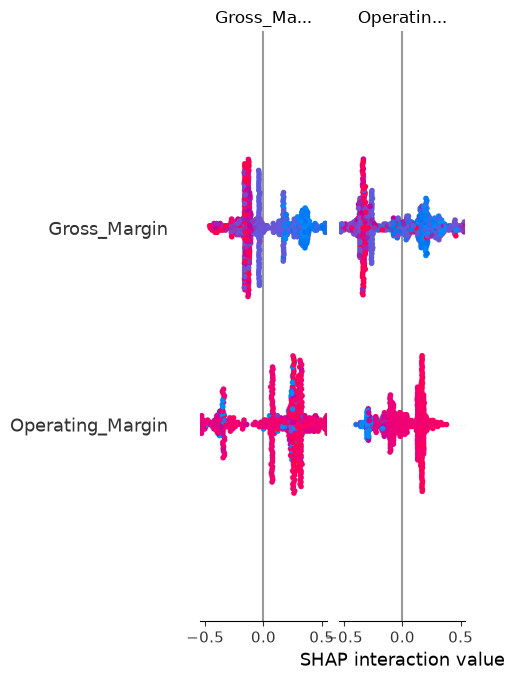

In [9]:
shap.summary_plot(
    shap_values,
    X_test
)

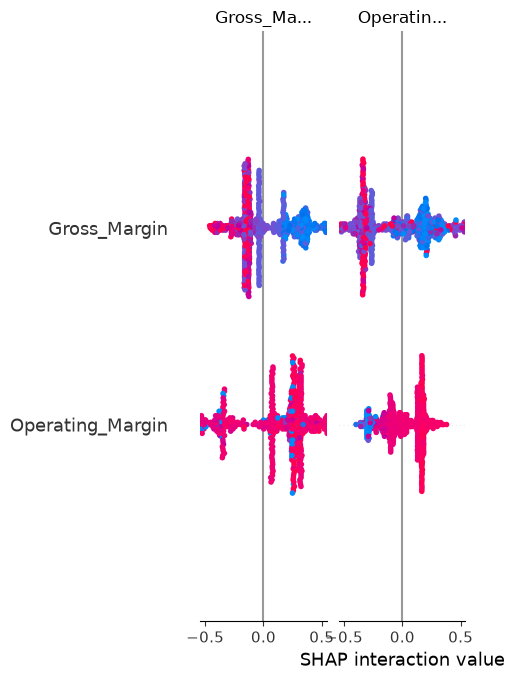

In [13]:
shap.summary_plot(
    shap_values,
    X_test,
    plot_type="bar"
)

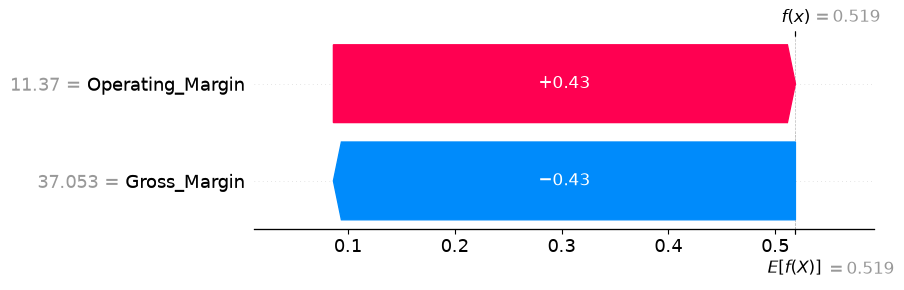

In [29]:
shap.plots.waterfall(
    shap.Explanation(
        values=shap_values[1][0],
        base_values=explainer.expected_value[1],
        data=X_test.iloc[0],
        feature_names=X_test.columns

    )
)

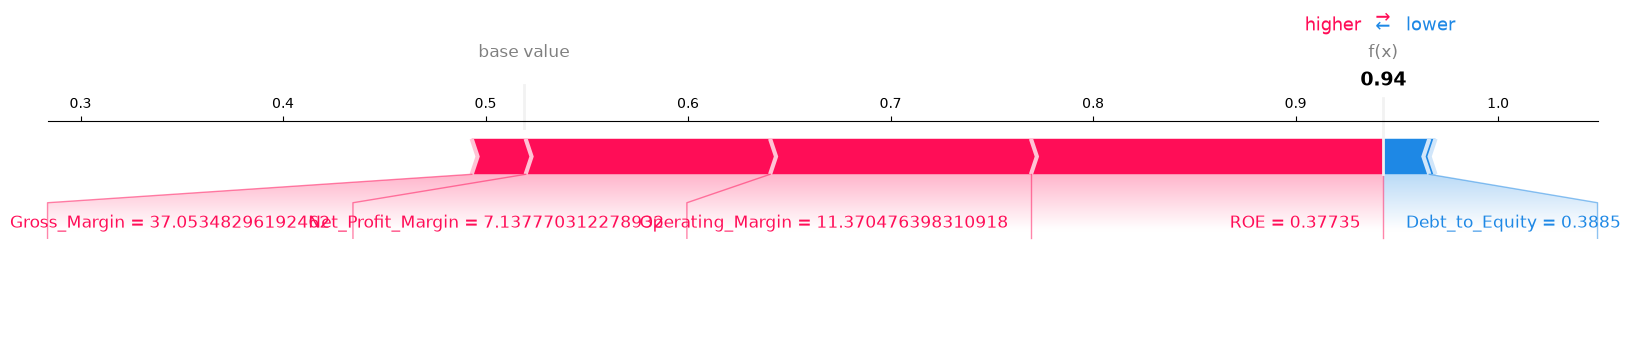

In [32]:
sample=0
shap.force_plot(
    explainer.expected_value[1],
    shap_values[sample,:,1], 
    X_test.iloc[sample],
    matplotlib=True
)

In [33]:
print(type(shap_values))
print(type(X_test))

print("X_test shape:", X_test.shape)

if isinstance(shap_values, list):
    for i, sv in enumerate(shap_values):
        print(i, sv.shape)
else:
    print("SHAP shape:", shap_values.shape)

<class 'numpy.ndarray'>
<class 'pandas.DataFrame'>
X_test shape: (762, 6)
SHAP shape: (762, 6, 2)


In [34]:
print(X_test.columns)
print(len(X_test.columns))

Index(['Gross_Margin', 'Operating_Margin', 'Net_Profit_Margin', 'ROE',
       'Debt_to_Assets', 'Debt_to_Equity'],
      dtype='str')
6


In [35]:
print(type(model))
print(type(explainer))

<class 'sklearn.ensemble._forest.RandomForestClassifier'>
<class 'shap.explainers._tree.TreeExplainer'>


In [36]:
shap_values_class1=shap_values[:,:,1]
print(shap_values_class1.shape)

(762, 6)


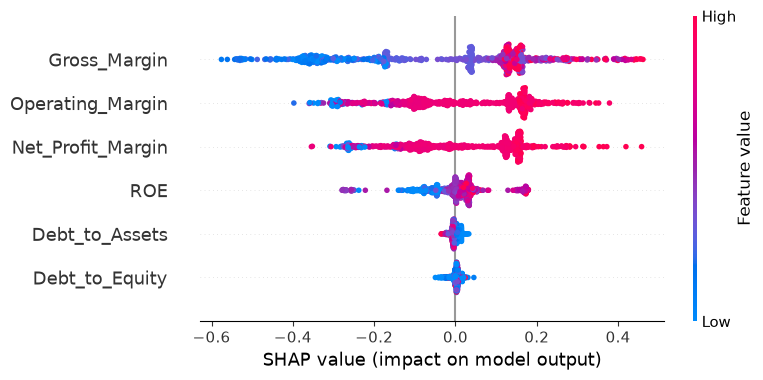

In [37]:
shap.summary_plot(
    shap_values_class1,
    X_test,
    feature_names=X_test.columns
)

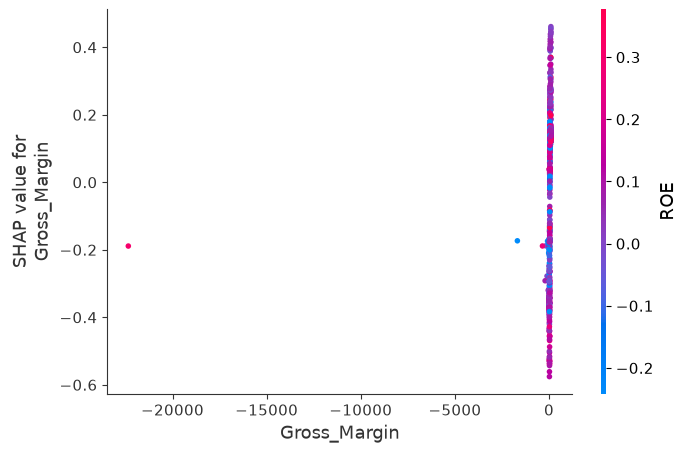

In [38]:
shap.dependence_plot(
    0,
    shap_values_class1,
    X_test
)

In [40]:
importance = pd.DataFrame({
    "Feature":features,
    "Importance":model.feature_importances_
})
importance = importance.sort_values(
    by="Importance",
    ascending=False
)
importance.to_csv(
    "SHAP_Feature_Importance.csv",
    index=False
)
print(importance)

             Feature  Importance
0       Gross_Margin    0.314008
1   Operating_Margin    0.291822
2  Net_Profit_Margin    0.258940
3                ROE    0.097712
5     Debt_to_Equity    0.019714
4     Debt_to_Assets    0.017804
